In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
sobar = pd.read_csv("sobar-72.csv")
sobar.head()
sobar.info()
print(sobar)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   behavior_sexualRisk         72 non-null     int64
 1   behavior_eating             72 non-null     int64
 2   behavior_personalHygine     72 non-null     int64
 3   intention_aggregation       72 non-null     int64
 4   intention_commitment        72 non-null     int64
 5   attitude_consistency        72 non-null     int64
 6   attitude_spontaneity        72 non-null     int64
 7   norm_significantPerson      72 non-null     int64
 8   norm_fulfillment            72 non-null     int64
 9   perception_vulnerability    72 non-null     int64
 10  perception_severity         72 non-null     int64
 11  motivation_strength         72 non-null     int64
 12  motivation_willingness      72 non-null     int64
 13  socialSupport_emotionality  72 non-null     int64
 14  socialSuppor

In [4]:
# Subset dataset to variables being used
cols_q2 = [
    "behavior_sexualRisk",
    "empowerment_knowledge",        # key predictor
    "perception_vulnerability",     # perceptual variable
    "socialSupport_instrumental",   # access control
    "intention_aggregation",        
    "intention_commitment",
    "attitude_consistency"
]

sobar_q2 = sobar[cols_q2].copy()

In [5]:
# Predictors
predictors = [
    "empowerment_knowledge",
    "perception_vulnerability",
    "socialSupport_instrumental",
    "intention_aggregation",
    "intention_commitment",
    "attitude_consistency"
]

,Variable,VIF
0,const,69.064018
1,empowerment_knowledge,2.012598
2,perception_vulnerability,1.113306
3,socialSupport_instrumental,1.815125
4,intention_aggregation,1.191507
5,intention_commitment,1.087386
6,attitude_consistency,1.045314


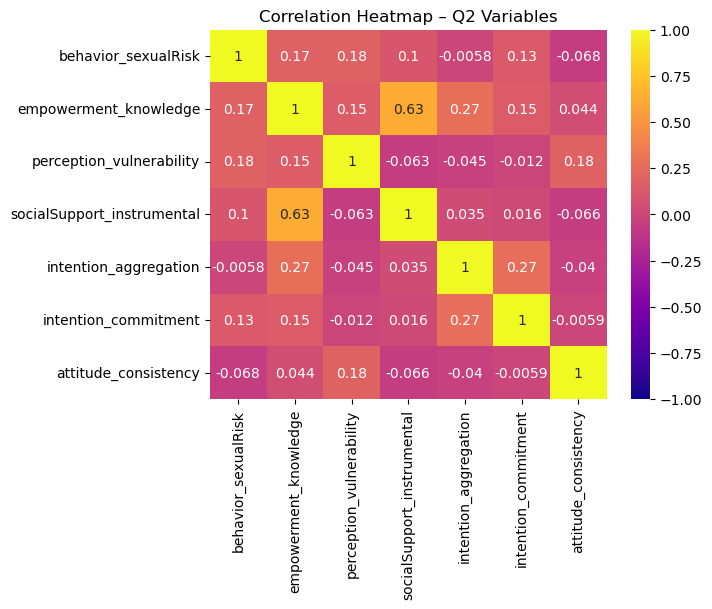

In [6]:
# Correlation matrix
sns.heatmap(sobar_q2.corr(),annot=True,cmap="plasma",vmin=-1, vmax=1)
plt.title("Correlation Heatmap – Q2 Variables"); 

# VIF
X_vif_q2 = sm.add_constant(sobar_q2[predictors])
vif_df_q2 = pd.DataFrame({
    "Variable": X_vif_q2.columns,
    "VIF": [variance_inflation_factor(X_vif_q2.values, i)
        for i in range(X_vif_q2.shape[1])]})

vif_df_q2

In [7]:
# Standardising predictors (all numerical)
for col in predictors:
    sobar_q2[col] = (sobar_q2[col] - sobar_q2[col].mean()) / sobar_q2[col].std()

In [8]:
# HEIRARCHICAL REGRESSION
# 1 - Empowerment + Perception + Access
y = sobar_q2["behavior_sexualRisk"]
block1_vars = ["empowerment_knowledge","perception_vulnerability","socialSupport_instrumental"]
X1 = sm.add_constant(sobar_q2[block1_vars])
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                             OLS Regression Results                            
Dep. Variable:     behavior_sexualRisk   R-squared:                       0.054
Model:                             OLS   Adj. R-squared:                  0.012
Method:                  Least Squares   F-statistic:                     1.287
Date:                 Thu, 18 Dec 2025   Prob (F-statistic):              0.286
Time:                         13:23:01   Log-Likelihood:                -112.00
No. Observations:                   72   AIC:                             232.0
Df Residuals:                       68   BIC:                             241.1
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const     

In [9]:
# 2 - Adding Intentions & Attitudes
block2_vars = block1_vars + ["intention_aggregation","intention_commitment","attitude_consistency"]
X2 = sm.add_constant(sobar_q2[block2_vars])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                             OLS Regression Results                            
Dep. Variable:     behavior_sexualRisk   R-squared:                       0.081
Model:                             OLS   Adj. R-squared:                 -0.004
Method:                  Least Squares   F-statistic:                    0.9502
Date:                 Thu, 18 Dec 2025   Prob (F-statistic):              0.466
Time:                         13:23:02   Log-Likelihood:                -110.96
No. Observations:                   72   AIC:                             235.9
Df Residuals:                       65   BIC:                             251.9
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const     

In [10]:
# Assessing variance
r2_block1 = model1.rsquared # how much variance in sexual risk is explained by the predictors
r2_block2 = model2.rsquared # additional variance explained by adding intentions/attitudes
delta_r2 = r2_block2 - r2_block1
r2_block1, r2_block2, delta_r2

(np.float64(0.05371271265694866),
 np.float64(0.08063517624044525),
 np.float64(0.026922463583496592))

In [11]:
# Coefficients: Which predictors are strongest predictors of sexual risk 
y_std = (y - y.mean()) / y.std() # standardise target variable (z score)
X2_std = sobar_q2[block2_vars].apply(lambda col: (col - col.mean()) / col.std()) # standardise all predictors in block 2
X2_std = sm.add_constant(X2_std) # add intercept manually

model2_std = sm.OLS(y_std, X2_std).fit() # fit regression using standardised variables

# Extract coefficients
betas = model2_std.params
print(betas.round(3))

const                         0.000
empowerment_knowledge         0.140
perception_vulnerability      0.173
socialSupport_instrumental    0.021
intention_aggregation        -0.074
intention_commitment          0.127
attitude_consistency         -0.106
dtype: float64


/var/folders/30/4kvxn55152d8qd2g4yn5_x5h0000gn/T/ipykernel_38846/2608919756.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=beta_plot.index, y=beta_plot.values, palette=palette)


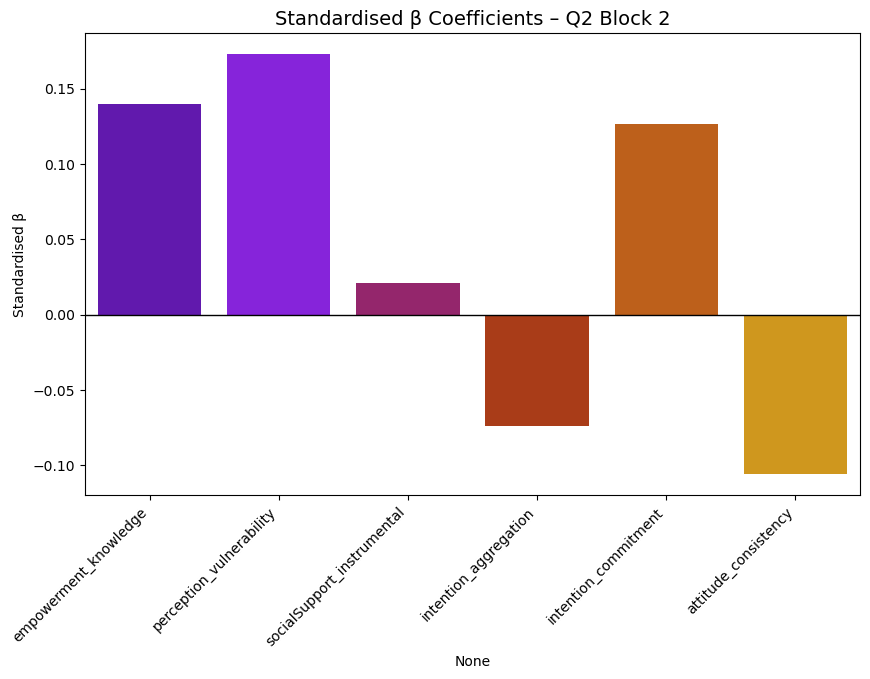

In [16]:
# Plotting coefficients
beta_plot = betas.drop("const").round(3)

plt.figure(figsize=(10,6))
palette = sns.color_palette("gnuplot", len(beta_plot))
sns.barplot(x=beta_plot.index, y=beta_plot.values, palette=palette)

# Add horizontal zero line
plt.axhline(0, color='black', linewidth=1)

# Improving text and spacing
plt.xticks(rotation=45, ha="right")
plt.ylabel("Standardised β")
plt.title("Standardised β Coefficients – Q2 Block 2", fontsize=14)

plt.show()

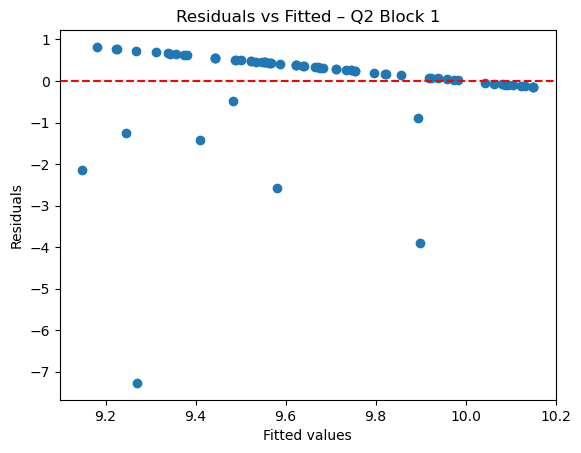

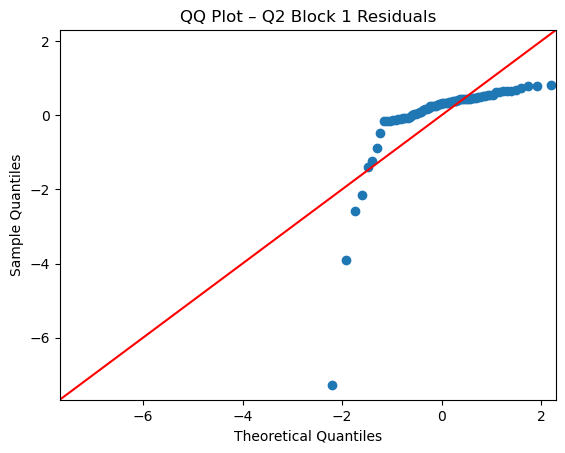

In [19]:
# Checking Regression Assumptions
# Extract model residuals and fitted values
resid = model1.resid
fitted = model1.fittedvalues

# Residuals vs Fitted Plot (linearity & homoscedasticity)
plt.scatter(fitted, resid)
plt.axhline(0, color="red", linestyle="--")   # reference line at zero residuals
plt.title("Residuals vs Fitted – Q2 Block 1")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()


# Q–Q Plot (normality)
sm.qqplot(resid, line='45')
plt.title("QQ Plot – Q2 Block 1 Residuals")
plt.show()

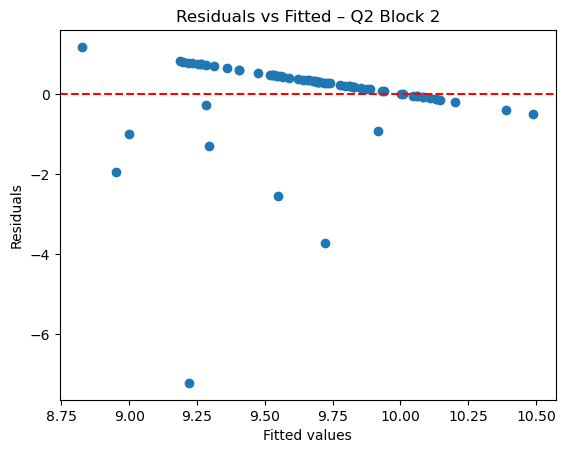

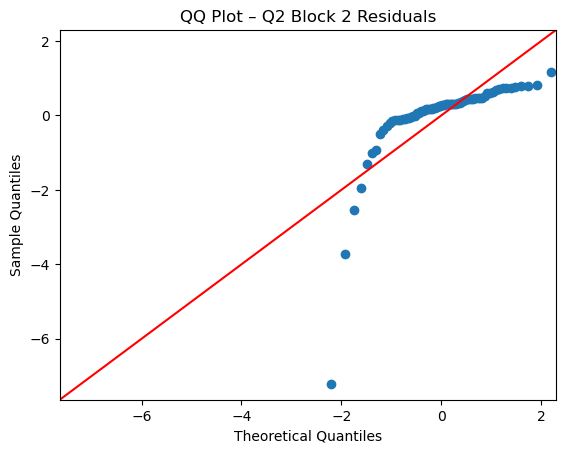

In [18]:
# Assumption checks for Block 2 model
resid2 = model2.resid
fitted2 = model2.fittedvalues

# Residuals vs Fitted
plt.scatter(fitted2, resid2)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Fitted – Q2 Block 2")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

# Q–Q Plot
sm.qqplot(resid2, line='45')
plt.title("QQ Plot – Q2 Block 2 Residuals")
plt.show()